In [1]:
# Read elevation raster
# ----------------------------
from pysheds.grid import Grid

grid = Grid.from_raster('dem2017subset.tif')
dem = grid.read_raster('dem2017subset.tif')

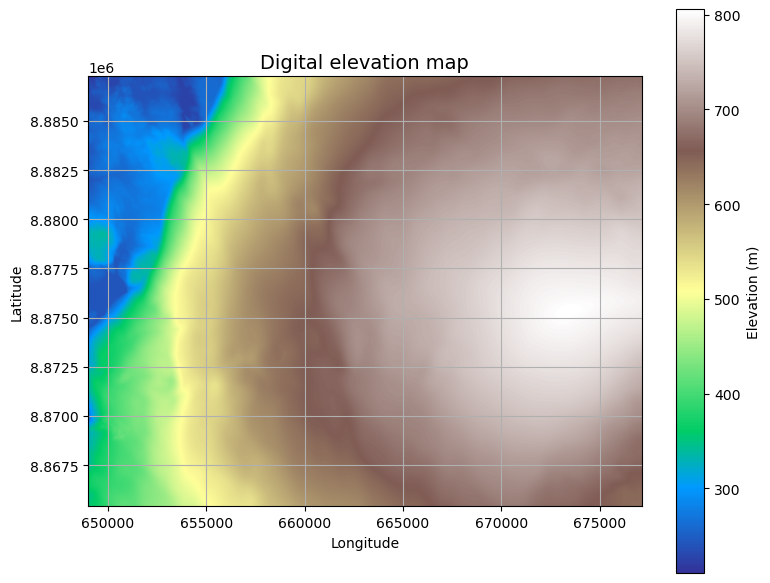

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='terrain', zorder=1)
plt.colorbar(label='Elevation (m)')
plt.grid(zorder=0)
plt.title('Digital elevation map', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

In [3]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)

In [4]:
# Determine D8 flow directions from DEM
# ----------------------
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

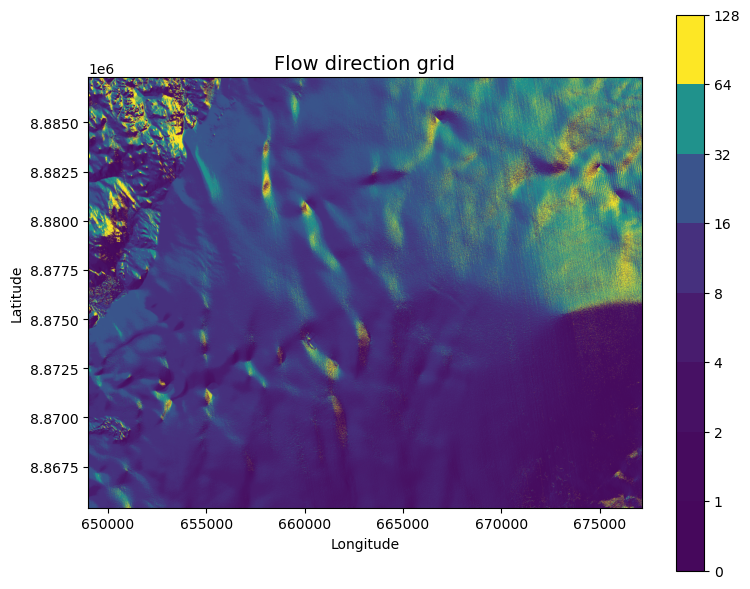

In [5]:
fig = plt.figure(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(fdir, extent=grid.extent, cmap='viridis', zorder=2)
boundaries = ([0] + sorted(list(dirmap)))
plt.colorbar(boundaries= boundaries,
             values=sorted(dirmap))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow direction grid', size=14)
plt.grid(zorder=-1)
plt.tight_layout()

In [6]:
# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir, dirmap=dirmap)

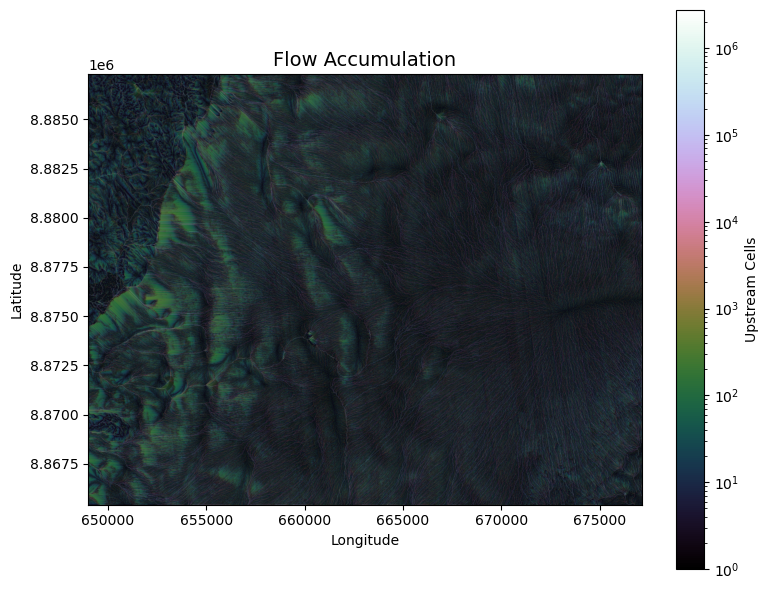

In [7]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()),
               interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.title('Flow Accumulation', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

In [8]:
import numpy as np

#acc_log10 = np.log10(acc)
#grid.to_raster(acc_log10, "flow_accumulation.tif")

In [13]:
# Delineate a catchment
# ---------------------
# Specify pour point
#x, y = -97.294, 32.737

import shapely
import geopandas as gpd
import pandas as pd
points = [
    {
        "x": 662163,
        "y": 8869260,
        "name": "ETN-5_weird_patch"
    },
    {
        "x": 673096,
        "y": 8882480,
        "name": "North of camp (brown patch)"

    },
    {
        "x": 668716,
        "y": 8879606,
        "name": "Patch towards core F"
    }
]

polygons = []
for point in points:

    # Snap pour point to high accumulation cell
    x_snap, y_snap = grid.snap_to_mask(acc > 1000, (point["x"], point["y"]))

    # Delineate the catchment
    catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                        xytype='coordinate')

    # Crop and plot the catchment
    # ---------------------------
    # Clip the bounding box to the catchment
    #grid.clip_to(catch)
    #clipped_catch = grid.view(catch)

    polygon = gpd.GeoDataFrame(geometry=[shapely.geometry.shape(shape) for shape, value in grid.polygonize(catch.astype("uint8")) if value == 1], crs=grid.crs)
    polygon["start_x"] = x_snap
    polygon["start_y"] = y_snap
    polygon["name"] = point["name"]

    polygons.append(polygon)

polygons = pd.concat(polygons)
polygons.to_file("catchments.geojson")